In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [6]:
root_dir = 'C:\\Users\\judad\\Downloads\\pneumonia\\chest_xray\\train'

In [10]:
image_paths = []
labels = []
classes = sorted(os.listdir(root_dir))
print(classes)
for label in classes:
    class_dir = os.path.join(root_dir,label)
    for fname in os.listdir(class_dir):
        fpath = os.path.join(class_dir,fname)
        if fpath.lower().endswith((".jpg",".jpeg",".png")):
            image_paths.append(fpath)
            labels.append(label)
print(len(image_paths))

['NORMAL', 'PNEUMONIA']
5216


In [17]:
from PIL import Image
def load_image(path,target_size=(48,48)):
    img = Image.open(path).convert('RGB')
    img = img.resize(target_size)
    return np.array(img)
X = np.array([load_image(p) for p in image_paths])
y = np.array(labels)    
print(X.shape)
print(y.shape)


(5216, 48, 48, 3)
(5216,)


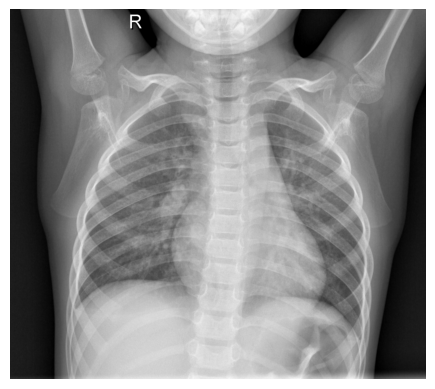

In [20]:
img = Image.open(image_paths[0])
plt.imshow(img,cmap = 'gray')
plt.axis('off')
plt.show()


In [24]:
val_dir = 'C:\\Users\\judad\\Downloads\\pneumonia\\chest_xray\\val'

In [27]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing import image_dataset_from_directory
train_ds = image_dataset_from_directory(
    root_dir,
    seed=123,
    image_size = (160,160),
    color_mode = 'grayscale',
    subset = 'training',
    validation_split = 0.2
)
val_ds = image_dataset_from_directory(
    root_dir,
    seed=123,
    image_size = (160,160),
    color_mode = 'grayscale',
    subset = 'validation',
    validation_split = 0.2
)

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.


In [43]:
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, Flatten, MaxPooling2D, Dense
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

data_augmentation = Sequential([
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1)
])
base_model.trainable = False

base_model = MobileNetV2(
    input_shape = (160,160,3),
    include_top = False,
    weights = 'imagenet'
)
model = Sequential([
    layers.Lambda(lambda x: tf.image.grayscale_to_rgb(x),input_shape=(160,160,1)),
    data_augmentation,
    layers.Lambda(preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    Dense(128,activation = 'relu',kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    Dropout(0.6),
    Dense(1,activation='sigmoid')
    
])
model.compile(optimizer=Adam(1e-4),loss="binary_crossentropy",metrics=['accuracy'])
model.summary()

C:\Users\judad\anaconda3\envs\tf-env\lib\site-packages\keras\src\layers\core\lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lambda_8 (Lambda)                    │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_8 (Sequential)            │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda_9 (Lambda)                    │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_160 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_4           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 2,387,969 (9.11 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [44]:
early_stop = keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    restore_best_weights = True
)
lr_schedule = keras.callbacks.ReduceLROnPlateau(
    monitor = 'val_loss',
    factor = 0.5,
    patience = 2
)

In [45]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight('balanced',classes = np.unique(y),y=y)

In [46]:
history = model.fit(train_ds,validation_data=val_ds,epochs=10,callbacks=[early_stop,lr_schedule],class_weight=dict(enumerate(class_weights)))

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.7638 - loss: 2.7054 - val_accuracy: 0.7766 - val_loss: 2.9933 - learning_rate: 1.0000e-04
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 0.9319 - loss: 2.1091 - val_accuracy: 0.7766 - val_loss: 2.9809 - learning_rate: 1.0000e-04
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.9444 - loss: 1.7587 - val_accuracy: 0.7766 - val_loss: 2.9367 - learning_rate: 1.0000e-04
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.9508 - loss: 1.4770 - val_accuracy: 0.7766 - val_loss: 2.7291 - learning_rate: 1.0000e-04
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.9592 - loss: 1.2324 - val_accuracy: 0.7766 - val_loss: 2.2850 - learning_rate: 1.0000e-04
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.9602 - loss: 1.0341 - val_accuracy: 0.7766 - val_loss: 2.7435 - learning_rate: 1.0000e-04
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - acc

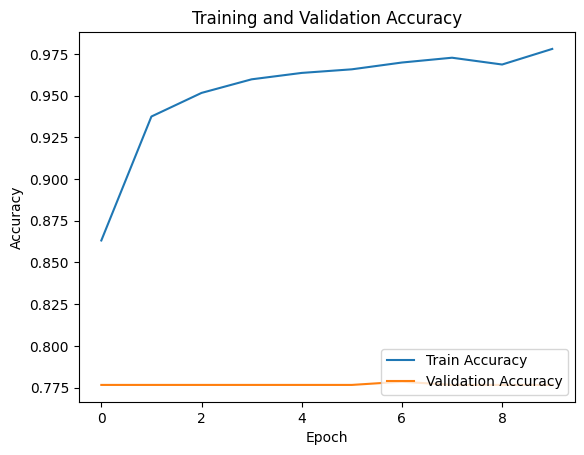

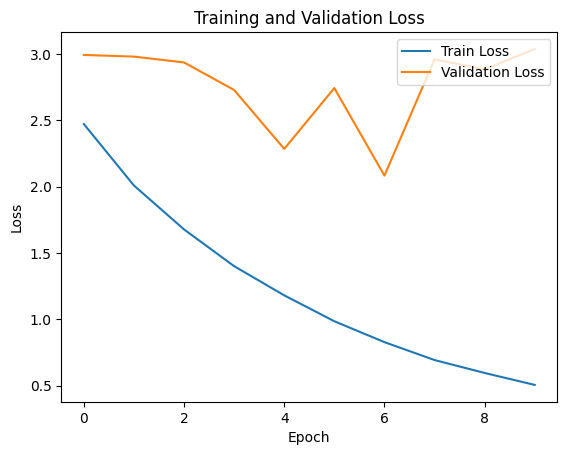

In [47]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 238s 2s/step - accuracy: 0.9756 - loss: 0.7519 - val_accuracy: 0.7766 - val_loss: 2.1752 - learning_rate: 1.0000e-05
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - accuracy: 0.9795 - loss: 0.7163 - val_accuracy: 0.7766 - val_loss: 2.3381 - learning_rate: 1.0000e-05
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.9786 - loss: 0.6880 - val_accuracy: 0.7766 - val_loss: 2.2875 - learning_rate: 1.0000e-05
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.9780 - loss: 0.6653 - val_accuracy: 0.7766 - val_loss: 2.1857 - learning_rate: 5.0000e-06
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 214s 2s/step - accuracy: 0.9800 - loss: 0.6622 - val_accuracy: 0.7766 - val_loss: 2.1083 - learning_rate: 5.0000e-06
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 266s 2s/step - accuracy: 0.9785 - loss: 0.6501 - val_accuracy: 0.7766 - val_loss: 2.0393 - learning_rate: 5.0000e-06
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 256s 2s/step - acc

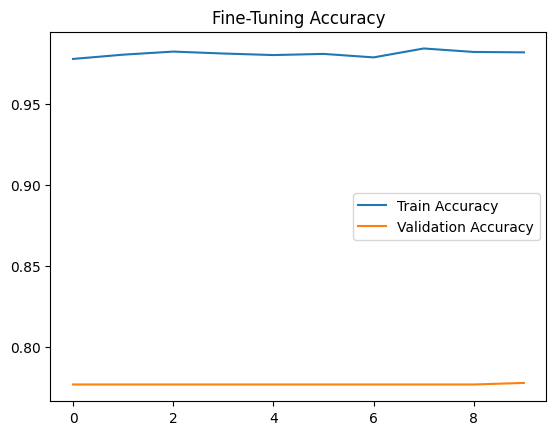

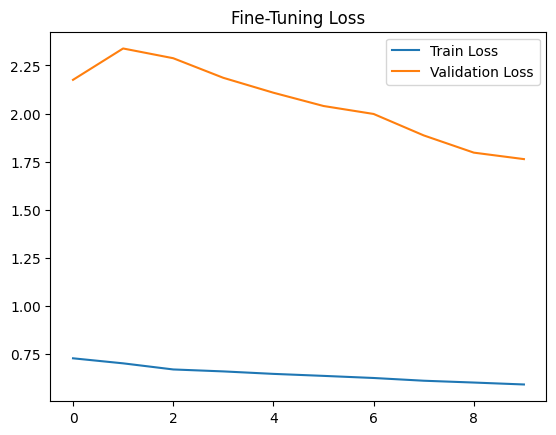

In [50]:
base_model.trainable=True
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),  # much smaller LR!
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, lr_schedule]
)
plt.plot(history_finetune.history['accuracy'], label='Train Accuracy')
plt.plot(history_finetune.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Fine-Tuning Accuracy')
plt.show()

plt.plot(history_finetune.history['loss'], label='Train Loss')
plt.plot(history_finetune.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Fine-Tuning Loss')
plt.show()